# Diabetes: Data Quality and Population Shift

Experiments on 30-day hospital readmission using Logistic Regression and LightGBM.


In [1]:
import json, os, subprocess, sys, textwrap, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

ROOT = os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "experiments"))
import common as C

RAW       = "raw_data/diabetic_data.csv"
SEEDS     = C.SEEDS
RUN_SUITE = os.environ.get("THESIS_RUN_SUITE", "1") == "1"
OUT       = os.environ.get("THESIS_NB_RESULTS", "results_notebook")
REFERENCE = "results"
RUN       = f"{OUT}/diabetes" if RUN_SUITE else f"{REFERENCE}/diabetes"

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from IPython.display import Image, display

def show_figure(name):

    local = f"{OUT}/figures/{name}"
    if os.path.exists(local):
        print(f"regenerated by this notebook: {local}")
        display(Image(filename=local))
    else:
        print(f"[reads stored results] thesis_project/figures/{name}")
        display(Image(filename=f"thesis_project/figures/{name}"))

print("seeds:", SEEDS, "| run suite:", RUN_SUITE, "| results read from:", RUN)
print(json.dumps(C.environment_record(), indent=2))

seeds: [42, 43, 44] | run suite: True | results read from: results_notebook/diabetes
{
  "timestamp": "2026-09-21 18:17:06",
  "python": "3.14.5",
  "platform": "macOS-26.6.2-arm64-arm-64bit-Mach-O",
  "pandas": "3.0.1",
  "numpy": "2.4.3",
  "scikit-learn": "1.8.0",
  "lightgbm": "4.6.0",
  "scipy": "1.17.1",
  "seeds": [
    42,
    43,
    44
  ],
  "argv": [
    "/opt/homebrew/lib/python3.14/site-packages/ipykernel_launcher.py",
    "-f",
    "/private/var/folders/f6/8b2d128x5618wrlbpj9wj1cc0000gn/T/tmpdt0z41jq.json",
    "--HistoryManager.hist_file=:memory:"
  ],
  "folktables": "0.0.12"
}


## 1. Data and Target

The UCI Diabetes dataset contains one row per hospital encounter. Readmission within 30 days is the positive class.

The loader replaces `?` with missing values and removes excluded columns.
Patient IDs are retained for splitting, but are not used as predictors.


In [2]:
df = C.load_diabetes(RAW)
X_all, y_all = C.diabetes_xy(df)

print(f"encounters            {len(df):,}")
print(f"unique patients       {df.patient_nbr.nunique():,}")
print(f"encounters / patient  {len(df)/df.patient_nbr.nunique():.2f}")
print(f"positive rate         {df.y.mean()*100:.2f}%  (readmitted within 30 days)")
print(f"predictors            {X_all.shape[1]}")
print(f"  numeric             {X_all.select_dtypes(include=np.number).shape[1]}")
print(f"  categorical         {X_all.select_dtypes(exclude=np.number).shape[1]}")
print("\ndropped in cleaning:  " + ", ".join(C.DIAB_DROP))
print("integer code columns kept as numeric: " + ", ".join(C.DIAB_ID_CODES))

encounters            101,766
unique patients       71,518
encounters / patient  1.42
positive rate         11.16%  (readmitted within 30 days)
predictors            42
  numeric             11
  categorical         31

dropped in cleaning:  encounter_id, weight, max_glu_serum, A1Cresult, payer_code, medical_specialty, readmitted
integer code columns kept as numeric: admission_type_id, discharge_disposition_id, admission_source_id


The main pipeline treats the three `*_id` fields as numbers. Section 13 checks the effect of treating them as categories.


## 2. Shifted Population

The shifted group contains encounters with `admission_source_id == 17`, labelled
`NULL` in the data dictionary. Their admission source was not recorded; the reason is unknown.


In [3]:
raw = pd.read_csv(RAW, low_memory=False).replace("?", np.nan)
raw["y"] = (raw.readmitted == "<30").astype(int)
sh, src = raw[raw.admission_source_id == 17], raw[raw.admission_source_id != 17]

rows = [
    ("Encounters",                                   lambda d: f"{len(d):,}"),
    ("Unique patients",                              lambda d: f"{d.patient_nbr.nunique():,}"),
    ("Encounters per patient",                       lambda d: f"{len(d)/d.patient_nbr.nunique():.2f}"),
    ("Readmitted <30 days (%)",                      lambda d: f"{d.y.mean()*100:.2f}"),
    ("Admission type NULL / Not Available (%)",      lambda d: f"{d.admission_type_id.isin([5,6]).mean()*100:.1f}"),
    ("Discharge disposition 1, home (%)",            lambda d: f"{(d.discharge_disposition_id==1).mean()*100:.1f}"),
    ("Payer code missing (%)",                       lambda d: f"{d.payer_code.isna().mean()*100:.1f}"),
    ("Medical specialty missing (%)",                lambda d: f"{d.medical_specialty.isna().mean()*100:.1f}"),
    ("Race missing (%)",                             lambda d: f"{d.race.isna().mean()*100:.1f}"),
    ("Race Caucasian (%)",                           lambda d: f"{(d.race=='Caucasian').mean()*100:.1f}"),
    ("Race African American (%)",                    lambda d: f"{(d.race=='AfricanAmerican').mean()*100:.1f}"),
    ("Age 70 or older (%)",                          lambda d: f"{d.age.isin(['[70-80)','[80-90)','[90-100)']).mean()*100:.1f}"),
    ("Mean lab procedures",                          lambda d: f"{d.num_lab_procedures.mean():.1f}"),
    ("Mean time in hospital (days)",                 lambda d: f"{d.time_in_hospital.mean():.2f}"),
    ("Mean prior emergency visits",                  lambda d: f"{d.number_emergency.mean():.2f}"),
    ("Mean prior inpatient visits",                  lambda d: f"{d.number_inpatient.mean():.2f}"),
]
cohort = pd.DataFrame({"Shifted cohort": [f(sh) for _, f in rows],
                       "Source population": [f(src) for _, f in rows]},
                      index=[lab for lab, _ in rows])
shared = len(set(sh.patient_nbr) & set(src.patient_nbr))
print(f"patients appearing in both the cohort and the source population: {shared:,}\n")
cohort

patients appearing in both the cohort and the source population: 73



,Shifted cohort,Source population
Encounters,"6,781","94,985"
Unique patients,"4,960","66,631"
Encounters per patient,1.37,1.43
Readmitted <30 days (%),10.41,11.21
Admission type NULL / Not Available (%),87.1,4.4
"Discharge disposition 1, home (%)",47.6,60.0
Payer code missing (%),74.5,37.1
Medical specialty missing (%),36.8,50.0
Race missing (%),1.2,2.3
Race Caucasian (%),86.6,73.9


The groups differ in readmission rate, administrative coding and patient characteristics. Some patients appear in both groups.


## 3. Patient-Disjoint Splitting

A patient can have several encounters. Splitting individual encounters can put the same
patient in training and testing (Saeb et al., 2017). The next cell measures this overlap;
it is a diagnostic, not the evaluation split.


In [4]:
rec = C.split_audit(C.split_diabetes_record(df, 42))
o, n_te = rec["overlap"]["train|test"], rec["test"]["encounters"]
print("record-level split, seed 42")
print(f"  in-domain test encounters            {n_te:,}")
print(f"  patients also present in training    {o['shared_patients']:,}")
print(f"  test encounters from those patients  {o['test_encounters_from_shared']:,}"
      f"  ({o['test_encounters_from_shared']/n_te*100:.1f}%)")
print(f"  shifted-cohort encounters affected   "
      f"{rec['overlap']['train|shifted']['shifted_encounters_from_shared']:,}")

record-level split, seed 42
  in-domain test encounters            14,248
  patients also present in training    4,715
  test encounters from those patients  5,542  (38.9%)
  shifted-cohort encounters affected   53


For evaluation, patients in the shifted group are reserved first and their other encounters
are removed from the source pool. The remaining patients are split 70/15/15 into training,
validation and test sets. Every encounter stays with its patient.


In [5]:
parts = C.split_diabetes_patient_disjoint(df, 42)
audit = C.split_audit(parts)

print(pd.DataFrame({k: {"encounters": v["encounters"], "patients": v["patients"],
                        "prevalence %": round(v["prevalence"]*100, 2)}
                    for k, v in audit.items() if k != "overlap"}).T.to_string())
print("\npairwise patient overlap:")
for pair, o in audit["overlap"].items():
    print(f"  {pair:<18} shared patients = {o['shared_patients']}")
C.assert_patient_disjoint(parts)
print("\nassert_patient_disjoint: passed (no patient appears in two partitions)")

         encounters    patients  prevalence %
train   66,447.0000 46,591.0000       11.1100
val     14,249.0000  9,984.0000       11.5400
test    14,192.0000  9,983.0000       11.3200
shifted  6,781.0000  4,960.0000       10.4100

pairwise patient overlap:
  train|val          shared patients = 0
  train|test         shared patients = 0
  train|shifted      shared patients = 0
  val|test           shared patients = 0
  val|shifted        shared patients = 0
  test|shifted       shared patients = 0

assert_patient_disjoint: passed (no patient appears in two partitions)


## 4. Preprocessing and Models

Numeric values are median-imputed and scaled for Logistic Regression. Categorical values
are filled with `missing` and one-hot encoded. Both models use balanced class weights.

No hyperparameters are tuned, so the validation set is unused.


In [6]:
Xtr, ytr = C.diabetes_xy(parts["train"])
Xte, yte = C.diabetes_xy(parts["test"])
Xsh, ysh = C.diabetes_xy(parts["shifted"])

models, cols = C.build_diabetes_models(Xtr, seed=42)
print(f"numeric columns     ({len(cols['numeric']):>2}): {', '.join(cols['numeric'])}")
print(f"categorical columns ({len(cols['categorical']):>2}): {', '.join(cols['categorical'][:8])} ...")
print()
for name, m in models.items():
    clf = m.named_steps["classifier"]
    print(f"{name:<20} {type(clf).__name__}(class_weight={clf.class_weight!r}, random_state={clf.random_state})")

numeric columns     (11): admission_type_id, discharge_disposition_id, admission_source_id, time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses
categorical columns (31): race, gender, age, diag_1, diag_2, diag_3, metformin, repaglinide ...

Logistic Regression  LogisticRegression(class_weight='balanced', random_state=42)
LightGBM             LGBMClassifier(class_weight='balanced', random_state=42)


## 5. Baseline Example

Fit both models with seed 42, then evaluate them on the in-domain and shifted populations.


In [7]:
demo = []
for name, m in models.items():
    m.fit(Xtr, ytr)
    for label, Xe, ye in [("In-domain Test", Xte, yte), ("Shifted Test", Xsh, ysh)]:
        p = m.predict_proba(Xe)[:, 1]
        demo.append({"Model": name, "Test Set": label, **C.metrics(ye, p), "mean predicted p": p.mean()})
demo = pd.DataFrame(demo)
gap = (demo[demo["Test Set"] == "Shifted Test"].set_index("Model")[["AUROC", "AUPRC", "Brier Score"]]
       - demo[demo["Test Set"] == "In-domain Test"].set_index("Model")[["AUROC", "AUPRC", "Brier Score"]])
print(demo.to_string(index=False))
print("\ndomain gap (shifted - in-domain), seed 42:")
print(gap.to_string())

              Model       Test Set  AUROC  AUPRC  Brier Score  mean predicted p
Logistic Regression In-domain Test 0.6398 0.1994       0.2235            0.4512
Logistic Regression   Shifted Test 0.6220 0.1833       0.2220            0.4478
           LightGBM In-domain Test 0.6838 0.2274       0.2113            0.4433
           LightGBM   Shifted Test 0.6576 0.2073       0.2173            0.4495

domain gap (shifted - in-domain), seed 42:
                      AUROC   AUPRC  Brier Score
Model                                           
Logistic Regression -0.0178 -0.0162      -0.0015
LightGBM            -0.0262 -0.0201       0.0060


## 6. Data-Quality Stress Tests

The following cells show training-label noise, training-set missingness and
feature removal at evaluation time.


In [8]:
ln = []
for rate in [0.0, 0.05, 0.10, 0.20]:
    yn = C.label_noise(ytr, rate, seed=42, style="diabetes")
    ln.append({"noise rate": rate, "labels flipped": int((yn != ytr).sum()),
               "train prevalence": yn.mean()})
print("label noise (training labels only, models refit, evaluation labels clean)")
print(pd.DataFrame(ln).to_string(index=False))

label noise (training labels only, models refit, evaluation labels clean)
 noise rate  labels flipped  train prevalence
     0.0000               0            0.1111
     0.0500            3322            0.1500
     0.1000            6644            0.1887
     0.2000           13289            0.2667


Random label flipping raises the positive rate on this imbalanced task. The intervention changes both label reliability and class prevalence.


In [9]:
print("columns eligible for masking:", ", ".join(C.DIAB_MISSING_COLS), "\n")
mrows = []
for sc in C.DIAB_MISSING_SCENARIOS:
    for rate in [0.10, 0.20]:
        if sc["type"] == "MCAR":
            Xn = C.mcar(Xtr, C.DIAB_MISSING_COLS, rate, seed=42, style="diabetes")
            elig = len(Xtr)
        else:
            cond = sc["condition"]
            mask = Xtr[cond["column"]].isin(cond["values"])
            Xn = C.mar(Xtr, C.DIAB_MISSING_COLS, rate, mask, seed=42, style="diabetes")
            elig = int(mask.sum())
        added = int(Xn[C.DIAB_MISSING_COLS].isna().sum().sum() - Xtr[C.DIAB_MISSING_COLS].isna().sum().sum())
        mrows.append({"mechanism": sc["label"], "rate": rate, "eligible rows": elig,
                      "cells newly missing": added})
print(pd.DataFrame(mrows).to_string(index=False))

columns eligible for masking: time_in_hospital, num_lab_procedures, race, diag_1 



    mechanism   rate  eligible rows  cells newly missing
         MCAR 0.1000          66447                26576
         MCAR 0.2000          66447                53156
   MAR_Female 0.1000          35778                14234
   MAR_Female 0.2000          35778                28470
MAR_Age_Older 0.1000          27982                11123
MAR_Age_Older 0.2000          27982                22246


For conditional missingness (MAR), the rate applies within the selected subgroup. The variable defining that subgroup remains observed.


In [10]:
for gname, gcols in C.DIAB_FEATURE_GROUPS.items():
    blanked = C.blank_out(Xte, gcols)
    seen = {c: ("missing" in Xtr[c].astype("object").fillna("missing").unique()) for c in gcols[:3]}
    print(f"{gname:<12} columns={len(gcols):>2}  missing cells after blanking="
          f"{int(blanked[gcols].isna().sum().sum()):,}  (= {len(Xte):,} rows x {len(gcols)} columns)")
print("\nshare of TRAINING rows where the column was already missing:")
print((Xtr[["diag_1", "diag_2", "diag_3"]].isna().mean()*100).round(3).to_string())
print((Xtr[C.MED_COLS[:3]].isna().mean()*100).round(3).to_string())

Diagnoses    columns= 3  missing cells after blanking=42,576  (= 14,192 rows x 3 columns)
Medications  columns=23  missing cells after blanking=326,416  (= 14,192 rows x 23 columns)

share of TRAINING rows where the column was already missing:
diag_1   0.0260
diag_2   0.3640
diag_3   1.4160
metformin     0.0000
repaglinide   0.0000
nateglinide   0.0000


Blanked medication columns produce an all-zero one-hot pattern absent from training.
Diagnosis columns use a `missing` category that was present, but rare, during training.

## 7. Run the Full Suite

Run all conditions over three seeds, the sensitivity checks, calibration analysis and
patient-clustered bootstrap. Figures using both datasets require the employment results too.


In [11]:
def run(cmd):
    print("$ " + " ".join(cmd[1:]), flush=True)
    r = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print("\n".join(r.stdout.strip().splitlines()[-4:]))
    if r.returncode:
        print(r.stderr[-2000:]); raise RuntimeError(f"failed: {' '.join(cmd)}")

if RUN_SUITE:
    P = sys.executable
    run([P, "experiments/run_diabetes.py", "--protocol", "patient", "--out", f"{OUT}/diabetes"])
    run([P, "experiments/run_diabetes.py", "--protocol", "patient", "--drop-admission-source",
         "--experiments", "baseline,feature_shift", "--out", f"{OUT}/diabetes_no_admission_source"])
    run([P, "experiments/run_diabetes.py", "--protocol", "patient", "--ids-categorical",
         "--experiments", "baseline,feature_shift", "--out", f"{OUT}/diabetes_ids_categorical"])
    run([P, "experiments/run_diabetes.py", "--protocol", "patient", "--no-class-weight",
         "--experiments", "baseline", "--out", f"{OUT}/diabetes_unweighted"])
    run([P, "experiments/analyze_predictions.py", "--run", f"{OUT}/diabetes",
         "--dataset", "diabetes", "--protocol", "patient", "--bootstrap", "1000"])
    run([P, "experiments/analyze_predictions.py", "--run", f"{OUT}/diabetes_unweighted",
         "--dataset", "diabetes", "--protocol", "patient"])
    # Combined figures require both datasets.
    run([P, "experiments/make_figures.py", "--results", OUT, "--out", f"{OUT}/figures"])
else:
    print("THESIS_RUN_SUITE=0: the suite was not run. The sections below read stored results from",
          REFERENCE)

$ experiments/run_diabetes.py --protocol patient --out results_notebook/diabetes


   missingness MCAR done (178s)
   missingness MAR_Female done (194s)
   missingness MAR_Age_Older done (209s)
DONE results_notebook/diabetes in 210s; rows=288
$ experiments/run_diabetes.py --protocol patient --drop-admission-source --experiments baseline,feature_shift --out results_notebook/diabetes_no_admission_source


[patient] seed 42: train=66447 test=14192 shifted=6781 predictors=41
[patient] seed 43: train=66336 test=14268 shifted=6781 predictors=41
[patient] seed 44: train=66382 test=14260 shifted=6781 predictors=41
DONE results_notebook/diabetes_no_admission_source in 17s; rows=54
$ experiments/run_diabetes.py --protocol patient --ids-categorical --experiments baseline,feature_shift --out results_notebook/diabetes_ids_categorical


[patient] seed 42: train=66447 test=14192 shifted=6781 predictors=42
[patient] seed 43: train=66336 test=14268 shifted=6781 predictors=42
[patient] seed 44: train=66382 test=14260 shifted=6781 predictors=42
DONE results_notebook/diabetes_ids_categorical in 17s; rows=54
$ experiments/run_diabetes.py --protocol patient --no-class-weight --experiments baseline --out results_notebook/diabetes_unweighted


[patient] seed 42: train=66447 test=14192 shifted=6781 predictors=42
[patient] seed 43: train=66336 test=14268 shifted=6781 predictors=42
[patient] seed 44: train=66382 test=14260 shifted=6781 predictors=42
DONE results_notebook/diabetes_unweighted in 13s; rows=18
$ experiments/analyze_predictions.py --run results_notebook/diabetes --dataset diabetes --protocol patient --bootstrap 1000


calibration written: 84 rows
blanking investigation written: 24 rows
bootstrap written
$ experiments/analyze_predictions.py --run results_notebook/diabetes_unweighted --dataset diabetes --protocol patient


calibration written: 12 rows
$ experiments/make_figures.py --results results_notebook --out results_notebook/figures


wrote fig_blanking_predictions
wrote fig_cross_stressor
wrote fig_missingness_delta
figures done


In [12]:
def load(run_dir, name="raw_results.csv"):
    # Keep "None" as a category label.
    return pd.read_csv(f"{run_dir}/{name}", keep_default_na=False, na_values=[""])

res = load(RUN)
ID, SH, GAP = "In-domain Test", "Shifted Test", "Generalization Gap (Shifted - In-domain)"
print(f"rows: {len(res):,}   seeds: {sorted(res['Random Seed'].unique())}")
print(res.groupby("Experiment").size().to_string())

rows: 288   seeds: [np.int64(42), np.int64(43), np.int64(44)]
Experiment
Baseline          18
Feature Shift     36
Label Noise       72
Missingness      162


## 8. Baseline and Calibration

Tables report means and standard deviations over three seeds. Domain gaps are calculated
within each seed before averaging.


In [13]:
def cell(d, exp, cond, model, tset, metric, **kw):
    q = d[(d.Experiment == exp) & (d.Condition == cond) & (d.Model == model) & (d["Test Set"] == tset)]
    for k, v in kw.items():
        q = q[q[k] == v]
    return q[metric].mean(), q[metric].std()

def table(d, exp, cond, tsets=(ID, SH, GAP), **kw):
    out = []
    for m in C.MODEL_NAMES:
        for met in ["AUROC", "AUPRC", "Brier Score"]:
            r = {"Model": m, "Metric": met}
            for t in tsets:
                mu, sd = cell(d, exp, cond, m, t, met, **kw)
                r[t] = f"{mu:.3f} ({sd:.3f})"
            out.append(r)
    return pd.DataFrame(out)

table(res, "Baseline", "None")

,Model,Metric,In-domain Test,Shifted Test,Generalization Gap (Shifted - In-domain)
0,Logistic Regression,AUROC,0.631 (0.009),0.624 (0.002),-0.007 (0.010)
1,Logistic Regression,AUPRC,0.198 (0.008),0.182 (0.002),-0.016 (0.006)
2,Logistic Regression,Brier Score,0.226 (0.003),0.224 (0.006),-0.003 (0.004)
3,LightGBM,AUROC,0.674 (0.009),0.661 (0.003),-0.014 (0.011)
4,LightGBM,AUPRC,0.224 (0.012),0.206 (0.003),-0.017 (0.009)
5,LightGBM,Brier Score,0.213 (0.002),0.214 (0.003),0.002 (0.004)


In [14]:
cal = pd.read_csv(f"{RUN}/calibration_per_seed.csv")
CALCOLS = ["Brier", "constant_baseline_Brier", "reliability", "resolution", "uncertainty",
           "ECE", "mean_pred", "prevalence"]
cal[cal.Experiment == "Baseline"].groupby(["Model", "Test Set"])[CALCOLS].mean().round(3)

Brier  constant_baseline_Brier  reliability  resolution  uncertainty    ECE  mean_pred  \
Model               Test Set                                                                                                 
LightGBM            In-domain Test 0.2130                   0.1020       0.1160      0.0050       0.1020 0.3280     0.4430   
                    Shifted Test   0.2140                   0.0930       0.1250      0.0040       0.0930 0.3400     0.4440   
Logistic Regression In-domain Test 0.2260                   0.1020       0.1270      0.0030       0.1020 0.3380     0.4530   
                    Shifted Test   0.2240                   0.0930       0.1320      0.0020       0.0930 0.3460     0.4500   

                                    prevalence  
Model               Test Set                    
LightGBM            In-domain Test      0.1150  
                    Shifted Test        0.1040  
Logistic Regression In-domain Test      0.1150  
                    Shifted Test        0.1040

Both models overestimate readmission probabilities under clean conditions. The next
comparison removes class weighting to examine its effect on calibration.


In [15]:
unw_dir = f"{OUT}/diabetes_unweighted" if RUN_SUITE else f"{REFERENCE}/diabetes_unweighted"
unw = pd.read_csv(f"{unw_dir}/calibration_per_seed.csv")
cmp = pd.concat([
    cal[cal.Experiment == "Baseline"].assign(fit="balanced class weights"),
    unw[unw.Experiment == "Baseline"].assign(fit="no class weights")])
cmp.groupby(["fit", "Model", "Test Set"])[
    ["ECE", "Brier", "constant_baseline_Brier", "mean_pred", "prevalence"]].mean().round(3)

ECE  Brier  constant_baseline_Brier  mean_pred  prevalence
fit                    Model               Test Set                                                                    
balanced class weights LightGBM            In-domain Test 0.3280 0.2130                   0.1020     0.4430      0.1150
                                           Shifted Test   0.3400 0.2140                   0.0930     0.4440      0.1040
                       Logistic Regression In-domain Test 0.3380 0.2260                   0.1020     0.4530      0.1150
                                           Shifted Test   0.3460 0.2240                   0.0930     0.4500      0.1040
no class weights       LightGBM            In-domain Test 0.0060 0.0970                   0.1020     0.1120      0.1150
                                           Shifted Test   0.0120 0.0900                   0.0930     0.1160      0.1040
                       Logistic Regression In-domain Test 0.0130 0.0990                   0.1020     0.1120      0.1150
                                           Shifted Test   0.0110 0.0910                   0.0930     0.1100      0.1040

Removing class weights substantially improves calibration while AUROC changes little. The weighted models remain the main analysis.


regenerated by this notebook: results_notebook/figures/fig_reliability_diabetes.png


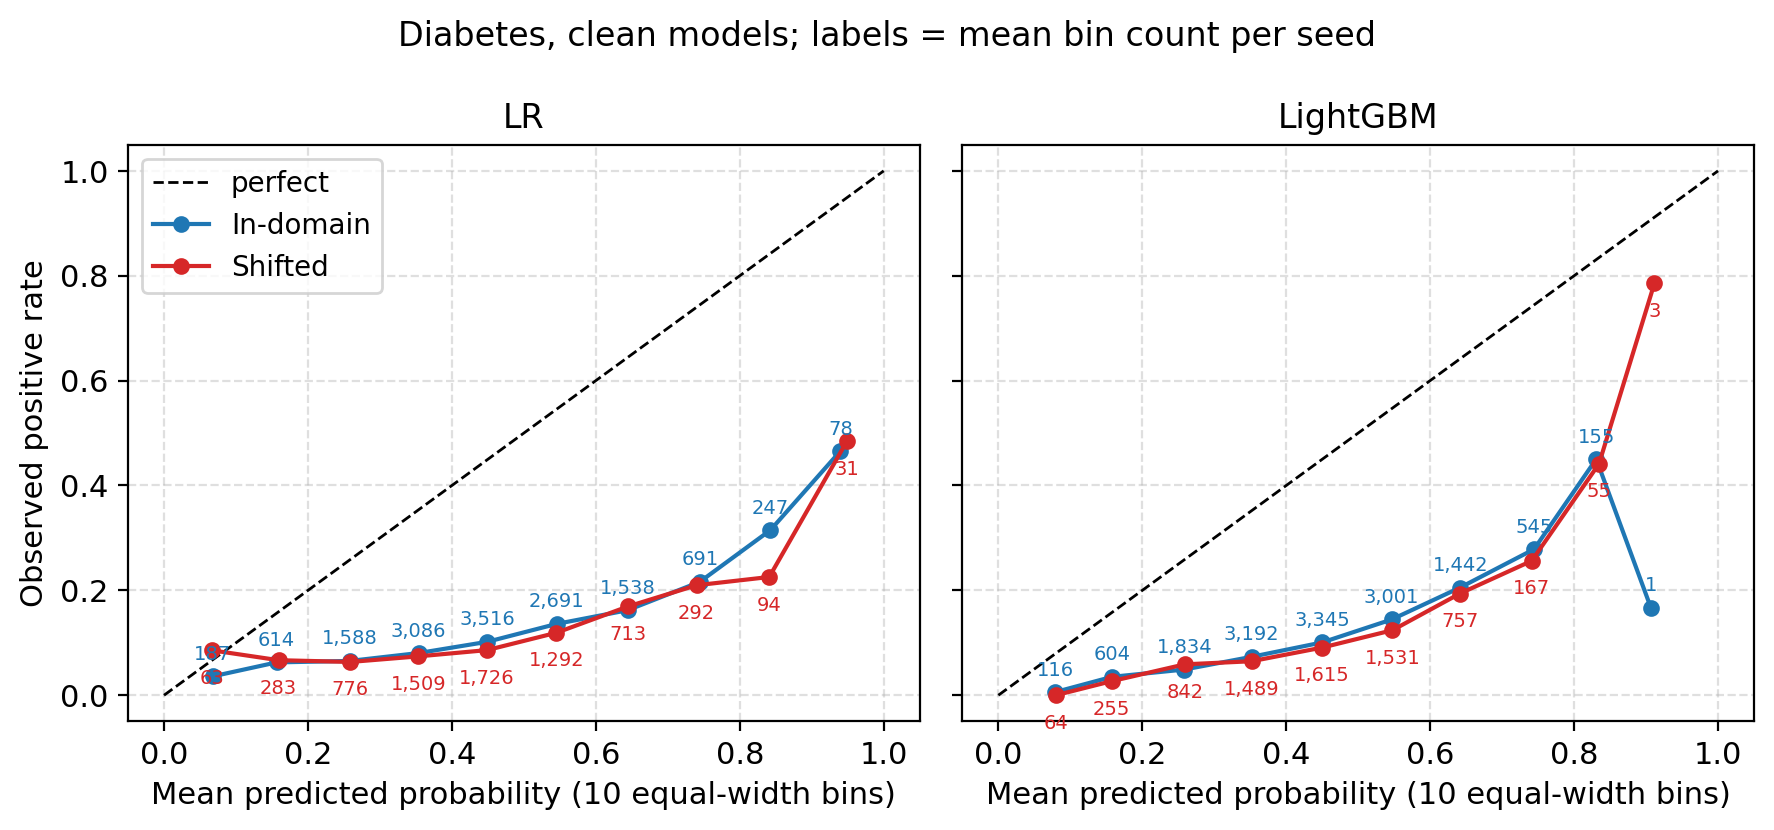

In [16]:
show_figure("fig_reliability_diabetes.png")

## 9. Label Noise

Flip training labels, refit the models and evaluate against unchanged test labels.


In [17]:
ln_tab = []
for m in C.MODEL_NAMES:
    for rate in [0.05, 0.10, 0.20]:
        r = {"Model": m, "noise": f"{rate:.0%}"}
        for t, lab in [(ID, "ID"), (SH, "SH")]:
            for met in ["AUROC", "Brier Score"]:
                a = res[(res.Experiment == "Label Noise") & (res["Noise Rate"] == rate) &
                        (res.Model == m) & (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                b = res[(res.Experiment == "Baseline") & (res.Model == m) &
                        (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                d = (a - b)
                r[f"d{met.split()[0]} {lab}"] = f"{d.mean():+.3f} ({d.std():.3f})"
        ln_tab.append(r)
pd.DataFrame(ln_tab)

,Model,noise,dAUROC ID,dBrier ID,dAUROC SH,dBrier SH
0,Logistic Regression,5%,-0.007 (0.004),+0.009 (0.001),+0.005 (0.001),+0.012 (0.006)
1,Logistic Regression,10%,-0.016 (0.004),+0.014 (0.001),-0.000 (0.005),+0.026 (0.006)
2,Logistic Regression,20%,-0.036 (0.001),+0.019 (0.002),-0.017 (0.008),+0.038 (0.007)
3,LightGBM,5%,-0.009 (0.002),+0.012 (0.001),-0.009 (0.005),+0.014 (0.000)
4,LightGBM,10%,-0.020 (0.004),+0.020 (0.001),-0.018 (0.016),+0.036 (0.021)
5,LightGBM,20%,-0.041 (0.002),+0.028 (0.001),-0.044 (0.024),+0.052 (0.042)


At 20% label noise, LightGBM loses about 0.04 AUROC on both populations. Changes are measured against each seed’s clean baseline.


regenerated by this notebook: results_notebook/figures/fig_label_noise.png


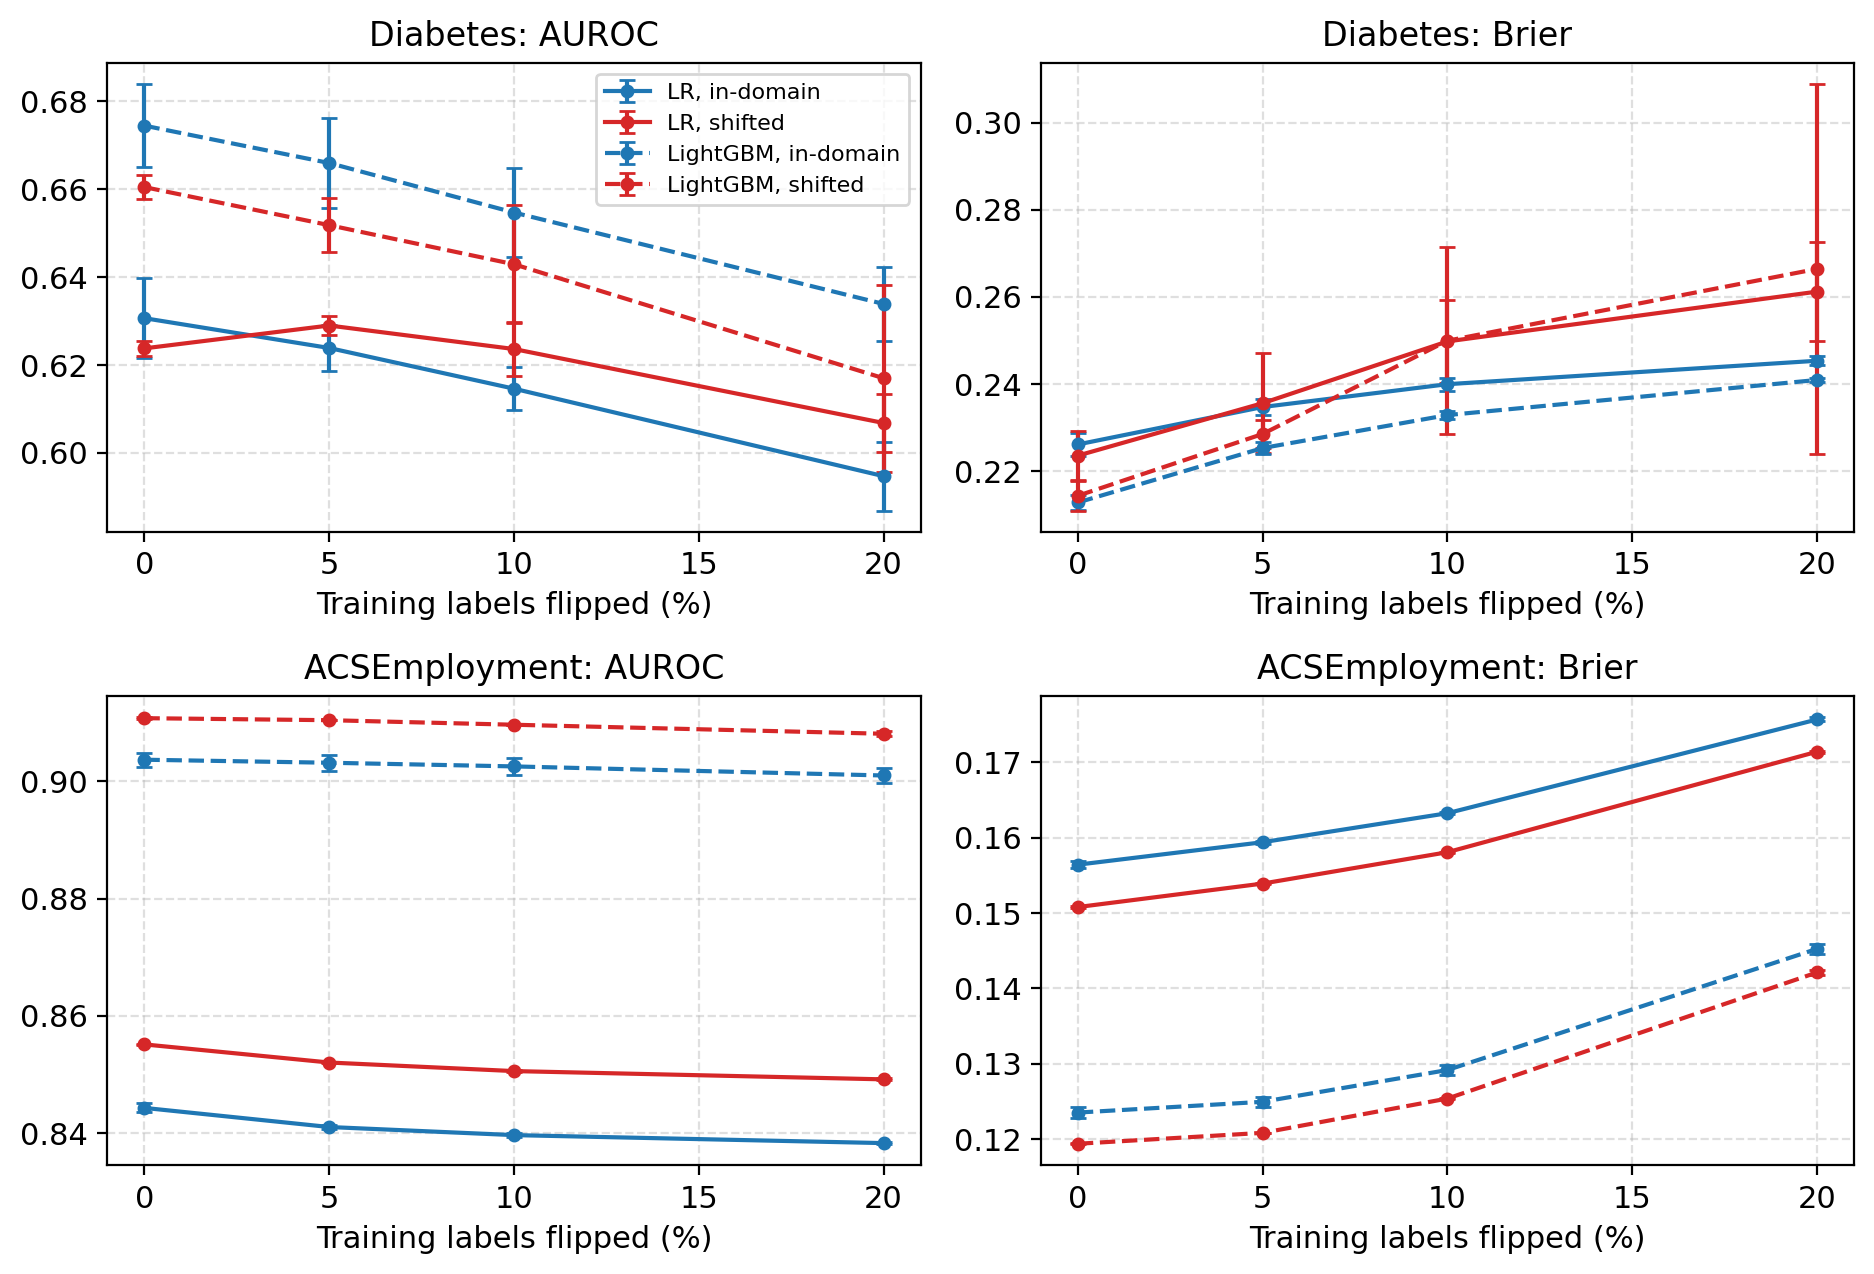

In [18]:
show_figure("fig_label_noise.png")

## 10. Missingness

Remove values from four training columns under three mechanisms, then refit.
Evaluation features remain unchanged.


In [19]:
ms = []
for m in C.MODEL_NAMES:
    for sc in ["MCAR", "MAR_Female", "MAR_Age_Older"]:
        r = {"Model": m, "mechanism": sc}
        for t, lab in [(ID, "ID"), (SH, "SH")]:
            a = res[(res.Experiment == "Missingness") & (res.Condition == sc) & (res["Missing Rate"] == 0.2) &
                    (res.Model == m) & (res["Test Set"] == t)].groupby("Random Seed")["AUROC"].mean()
            b = res[(res.Experiment == "Baseline") & (res.Model == m) &
                    (res["Test Set"] == t)].groupby("Random Seed")["AUROC"].mean()
            r[f"dAUROC {lab}"] = f"{(a-b).mean():+.4f} ({(a-b).std():.4f})"
        ms.append(r)
pd.DataFrame(ms)

,Model,mechanism,dAUROC ID,dAUROC SH
0,Logistic Regression,MCAR,-0.0002 (0.0023),-0.0020 (0.0024)
1,Logistic Regression,MAR_Female,+0.0007 (0.0021),-0.0009 (0.0011)
2,Logistic Regression,MAR_Age_Older,+0.0008 (0.0009),-0.0006 (0.0017)
3,LightGBM,MCAR,-0.0005 (0.0040),-0.0024 (0.0022)
4,LightGBM,MAR_Female,-0.0007 (0.0009),+0.0025 (0.0064)
5,LightGBM,MAR_Age_Older,-0.0014 (0.0017),+0.0004 (0.0027)


AUROC changes are small at the tested rates. This finding applies to these columns and
preprocessing choices, not to missing data generally.

## 11. Feature Unavailability

Blank whole feature groups in both test sets and apply the clean models without refitting.


In [20]:
fs = []
for m in C.MODEL_NAMES:
    for g in C.DIAB_FEATURE_GROUPS:
        r = {"Model": m, "blanked": g}
        for t, lab in [(ID, "ID"), (SH, "SH")]:
            for met in ["AUROC", "Brier Score"]:
                a = res[(res.Experiment == "Feature Shift") & (res.Condition == g) & (res.Model == m) &
                        (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                b = res[(res.Experiment == "Baseline") & (res.Model == m) &
                        (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                r[f"{met.split()[0]} {lab}"] = f"{a.mean():.3f} (d {a.mean()-b.mean():+.3f})"
        fs.append(r)
pd.DataFrame(fs)

,Model,blanked,AUROC ID,Brier ID,AUROC SH,Brier SH
0,Logistic Regression,Diagnoses,0.637 (d +0.006),0.386 (d +0.160),0.632 (d +0.008),0.393 (d +0.170)
1,Logistic Regression,Medications,0.630 (d -0.000),0.412 (d +0.186),0.621 (d -0.002),0.413 (d +0.190)
2,LightGBM,Diagnoses,0.668 (d -0.006),0.208 (d -0.005),0.658 (d -0.003),0.211 (d -0.003)
3,LightGBM,Medications,0.670 (d -0.005),0.193 (d -0.020),0.655 (d -0.005),0.191 (d -0.024)


In [21]:
inv = pd.read_csv(f"{RUN}/blanking_investigation.csv")
inv.groupby(["Model", "Feature Group Blanked", "Test Set"])[
    ["mean_pred_clean", "mean_pred_blanked", "corr_clean_blanked", "spearman_clean_blanked",
     "Brier_clean", "Brier_blanked", "AUROC_clean", "AUROC_blanked"]].mean().round(3)

mean_pred_clean  mean_pred_blanked  corr_clean_blanked  \
Model               Feature Group Blanked Test Set                                                                 
LightGBM            Diagnoses             In-domain Test           0.4430             0.4370              0.8990   
                                          Shifted Test             0.4440             0.4400              0.8980   
                    Medications           In-domain Test           0.4430             0.4090              0.9460   
                                          Shifted Test             0.4440             0.4060              0.9390   
Logistic Regression Diagnoses             In-domain Test           0.4530             0.6500              0.7150   
                                          Shifted Test             0.4500             0.6520              0.7060   
                    Medications           In-domain Test           0.4530             0.6630              0.9650   
                                          Shifted Test             0.4500             0.6610              0.9670   

                                                          spearman_clean_blanked  Brier_clean  Brier_blanked  AUROC_clean  \
Model               Feature Group Blanked Test Set                                                                          
LightGBM            Diagnoses             In-domain Test                  0.8900       0.2130         0.2080       0.6740   
                                          Shifted Test                    0.8890       0.2140         0.2110       0.6610   
                    Medications           In-domain Test                  0.9380       0.2130         0.1930       0.6740   
                                          Shifted Test                    0.9320       0.2140         0.1910       0.6610   
Logistic Regression Diagnoses             In-domain Test                  0.6850       0.2260         0.3860       0.6310   
                                          Shifted Test                    0.6740       0.2240         0.3930       0.6240   
                    Medications           In-domain Test                  0.9880       0.2260         0.4120       0.6310   
                                          Shifted Test                    0.9870       0.2240         0.4130       0.6240   

                                                          AUROC_blanked  
Model               Feature Group Blanked Test Set                       
LightGBM            Diagnoses             In-domain Test         0.6680  
                                          Shifted Test           0.6580  
                    Medications           In-domain Test         0.6700  
                                          Shifted Test           0.6550  
Logistic Regression Diagnoses             In-domain Test         0.6370  
                                          Shifted Test           0.6320  
                    Medications           In-domain Test         0.6300  
                                          Shifted Test           0.6210

Medication blanking raises Logistic Regression’s Brier score from about 0.22 to 0.40,
while largely preserving rankings. Diagnosis blanking also changes individual rankings.

Similar deterioration on both populations can be hidden by reporting only the domain gap.


regenerated by this notebook: results_notebook/figures/fig_blanking_predictions.png


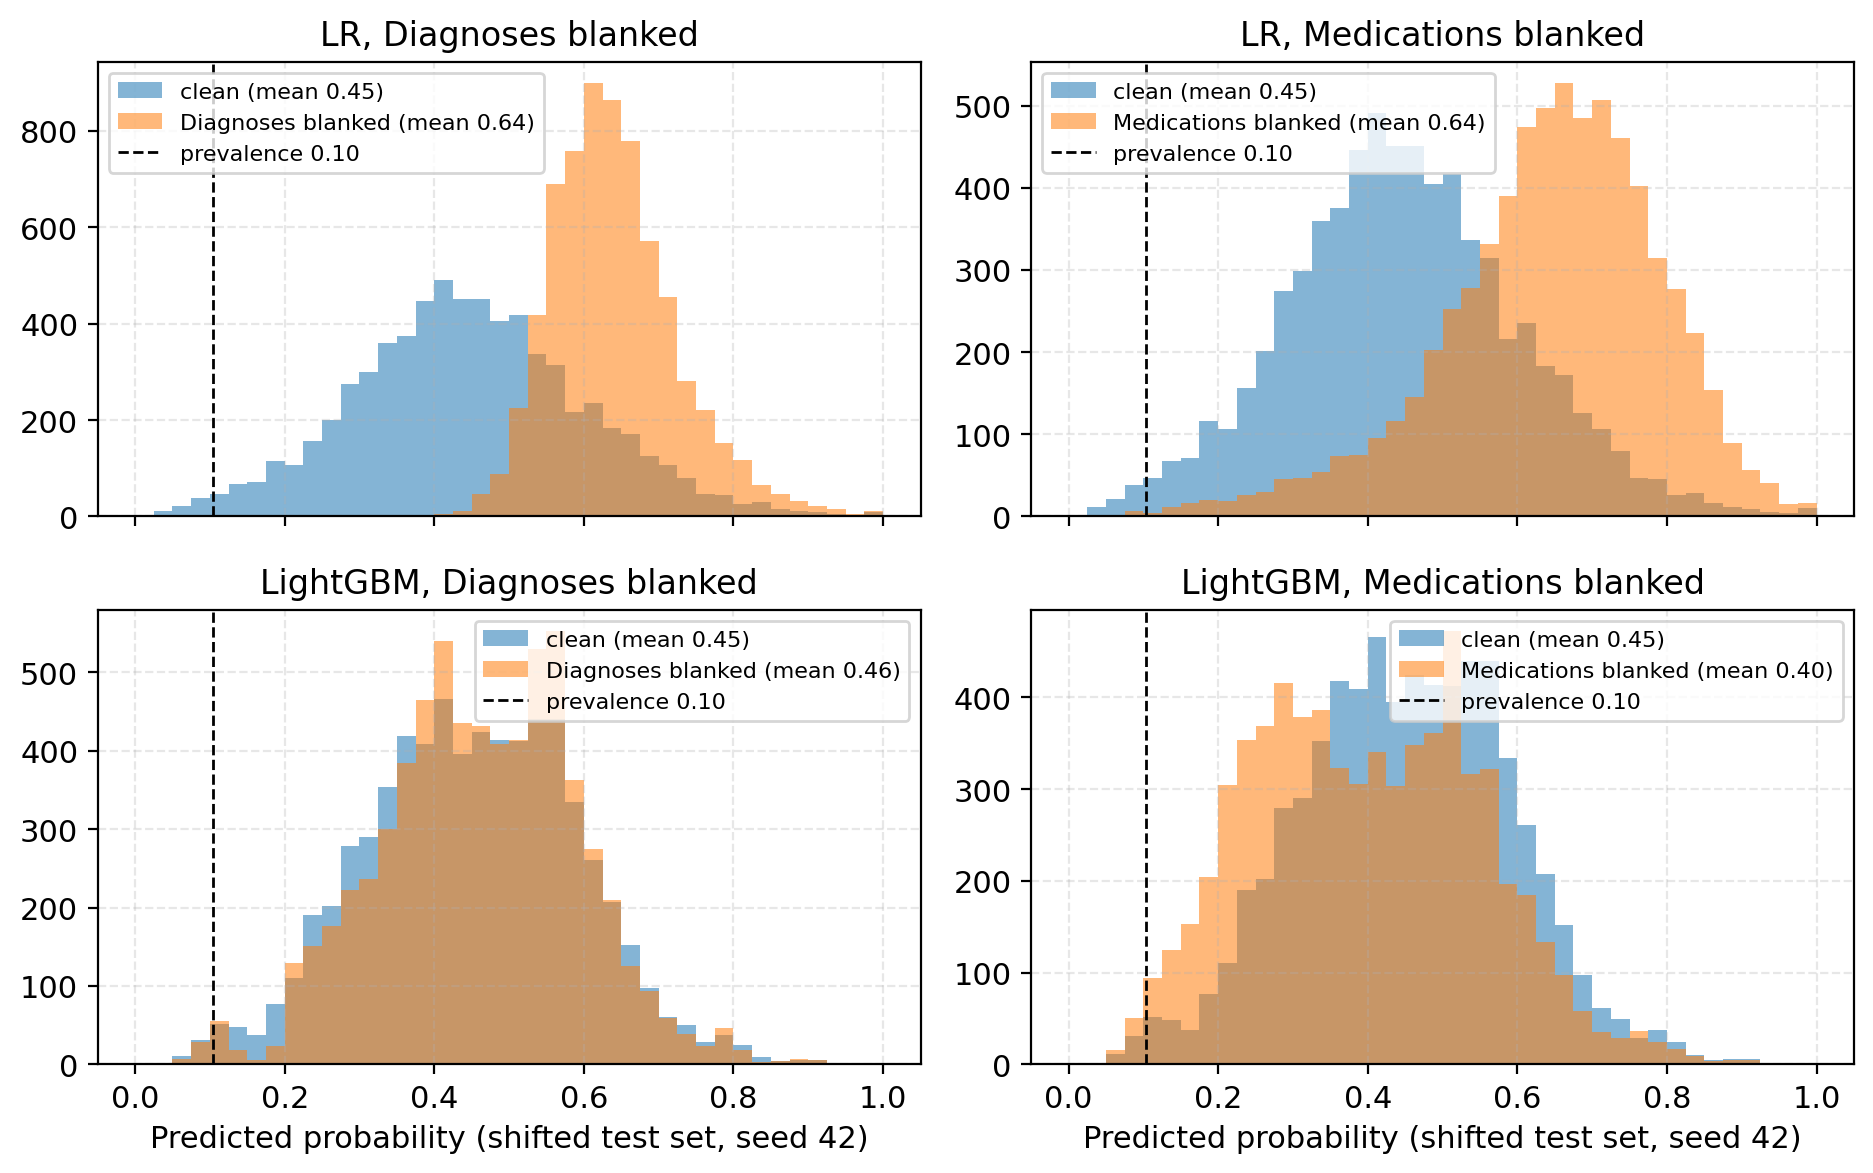

In [22]:
show_figure("fig_blanking_predictions.png")

## 12. Uncertainty

Across-seed standard deviations describe variation between splits and model fits.
The bootstrap resamples whole patients, keeping the fitted models fixed.


In [23]:
bs = pd.read_csv(f"{RUN}/bootstrap_clustered.csv")
print(f"{bs.B.iloc[0]:,} resamples of patients per seed, fitted models held fixed")
print("intervals averaged over the three seeds\n")
print(bs.pivot_table(index=["statistic", "model"], values=["boot_mean", "ci_lo", "ci_hi"],
                     aggfunc="mean")[["boot_mean", "ci_lo", "ci_hi"]].round(4).to_string())
print("\nper seed, difference between the two models' AUROC domain gaps:")
print(bs[bs.statistic == "diff_gap_AUROC_LGBM_minus_LR"][["Random Seed", "boot_mean", "ci_lo", "ci_hi"]]
      .round(4).to_string(index=False))

1,000 resamples of patients per seed, fitted models held fixed
intervals averaged over the three seeds

                                                      boot_mean   ci_lo  ci_hi
statistic                        model                                        
diff_gap_AUROC_LGBM_minus_LR     both                   -0.0071 -0.0301 0.0159
diff_shifted_AUROC_LGBM_minus_LR both                    0.0366  0.0171 0.0562
gap_AUPRC                        LightGBM               -0.0180 -0.0629 0.0317
gap_AUROC                        LightGBM               -0.0139 -0.0412 0.0155
                                 Logistic Regression    -0.0072 -0.0385 0.0241
gap_Brier                        LightGBM                0.0015 -0.0030 0.0060

per seed, difference between the two models' AUROC domain gaps:
 Random Seed  boot_mean   ci_lo  ci_hi
          42    -0.0087 -0.0323 0.0144
          43    -0.0060 -0.0277 0.0162
          44    -0.0067 -0.0302 0.0171


The bootstrap intervals for the difference between model AUROC gaps include zero.
LightGBM ranks better on both populations, but these intervals do not establish a larger shift penalty.

## 13. Sensitivity Checks

Compare the main pipeline with admission-source removal, categorical encoding of the
three code fields and removal of class weights.


In [24]:
variants = {"main": RUN,
            "without admission_source_id": (f"{OUT}/diabetes_no_admission_source" if RUN_SUITE
                                            else f"{REFERENCE}/diabetes_no_admission_source"),
            "id codes categorical":        (f"{OUT}/diabetes_ids_categorical" if RUN_SUITE
                                            else f"{REFERENCE}/diabetes_ids_categorical")}
sens = []
for label, d in variants.items():
    r = load(d)
    for m in C.MODEL_NAMES:
        sens.append({"variant": label, "Model": m,
                     "AUROC ID": f"{cell(r,'Baseline','None',m,ID,'AUROC')[0]:.3f}",
                     "AUROC SH": f"{cell(r,'Baseline','None',m,SH,'AUROC')[0]:.3f}",
                     "gap":      f"{cell(r,'Baseline','None',m,GAP,'AUROC')[0]:+.3f}"})
pd.DataFrame(sens)

,variant,Model,AUROC ID,AUROC SH,gap
0,main,Logistic Regression,0.631,0.624,-0.007
1,main,LightGBM,0.674,0.661,-0.014
2,without admission_source_id,Logistic Regression,0.631,0.624,-0.007
3,without admission_source_id,LightGBM,0.673,0.658,-0.015
4,id codes categorical,Logistic Regression,0.656,0.635,-0.021
5,id codes categorical,LightGBM,0.676,0.659,-0.017


Categorical encoding raises Logistic Regression’s in-domain AUROC from 0.631 to 0.656
and widens its gap from −0.007 to −0.021. Encoding therefore affects the model comparison.

## 14. Verification

Check patient separation, experiment coverage and agreement with the saved results.


In [25]:
audits = json.load(open(f"{RUN}/split_audit.json"))
bad = [(s, pair) for s, a in audits.items() for pair, o in a["overlap"].items() if o["shared_patients"]]
print("patient-disjoint in every seed:", not bad, "" if not bad else bad)

KEYS = ["Experiment", "Condition", "Noise Rate", "Missing Rate", "Feature Group Blanked",
        "Model", "Random Seed"]
got = (res[res["Test Set"] == ID].drop_duplicates(KEYS).groupby("Experiment").size()
       // (len(C.MODEL_NAMES) * len(SEEDS)))
print("\nconditions per experiment (methods chapter: baseline 1, label noise 4, missingness 9, blanking 2)")
print(got.to_string())
print("\nseeds:", sorted(int(s) for s in res["Random Seed"].unique()), "expected", SEEDS)

patient-disjoint in every seed: True 

conditions per experiment (methods chapter: baseline 1, label noise 4, missingness 9, blanking 2)
Experiment
Baseline         1
Feature Shift    2
Label Noise      4
Missingness      9

seeds: [42, 43, 44] expected [42, 43, 44]


In [26]:
if RUN_SUITE:
    a = load(RUN).sort_values(list(load(RUN).columns)).reset_index(drop=True)
    b = load(f"{REFERENCE}/diabetes").sort_values(list(load(RUN).columns)).reset_index(drop=True)
    num = ["AUROC", "AUPRC", "Brier Score"]
    same_shape = a.shape == b.shape
    worst = float(np.abs(a[num].to_numpy() - b[num].to_numpy()).max()) if same_shape else float("nan")
    print(f"rows {a.shape[0]:,} vs {b.shape[0]:,}   identical shape: {same_shape}")
    print(f"largest absolute difference against the submitted results: {worst:.3e}")
    assert same_shape and worst < 1e-12, "this run does not reproduce the submitted results"
    print("PASS: the run reproduces the submitted results exactly")
else:
    print("[reads stored results] comparison skipped because the suite was not run")

rows 288 vs 288   identical shape: True
largest absolute difference against the submitted results: 0.000e+00
PASS: the run reproduces the submitted results exactly


## 15. Main Findings

- Label noise causes the largest discrimination losses in the tested Diabetes conditions.
- Training-set missingness has small effects at the tested rates.
- Feature removal can distort probabilities while leaving aggregate ranking largely unchanged.
- Balanced class weighting explains the poor baseline calibration.

See [ACSEmployment.ipynb](ACSEmployment.ipynb) for the second dataset and the comparison
of in-domain and shifted responses.
